In [22]:
import pandas as pd

df = pd.read_csv("cleaned_visa_feature_engineered_dataset.csv")

df.head()

,CASE_STATUS,VISA_CLASS,FULL_TIME_POSITION,EMPLOYER_STATE,WORKSITE_STATE,WAGE_RATE_OF_PAY_FROM,PREVAILING_WAGE,processing_days,wage_ratio,application_month,state_processing_avg,worksite_processing_avg
0,Certified,1,1,34,10,-0.283237,-0.263317,5,1.075650,9,8.305479,8.551642
1,Certified,1,1,24,23,-0.735466,-1.052168,5,0.699000,9,9.646314,9.437536
2,Certified,1,1,9,20,-0.687250,-0.975133,5,0.704775,9,8.897912,9.385678
3,Certified,1,1,25,24,-0.735731,-1.110884,5,0.662294,9,9.010886,8.624650
4,Certified,1,1,47,45,-0.556892,-0.695744,5,0.800427,9,8.434844,8.420480


In [23]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194751 entries, 0 to 194750
Data columns (total 12 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   CASE_STATUS              194751 non-null  object 
 1   VISA_CLASS               194751 non-null  int64  
 2   FULL_TIME_POSITION       194751 non-null  int64  
 3   EMPLOYER_STATE           194751 non-null  int64  
 4   WORKSITE_STATE           194751 non-null  int64  
 5   WAGE_RATE_OF_PAY_FROM    194751 non-null  float64
 6   PREVAILING_WAGE          194751 non-null  float64
 7   processing_days          194751 non-null  int64  
 8   wage_ratio               194751 non-null  float64
 9   application_month        194751 non-null  int64  
 10  state_processing_avg     194751 non-null  float64
 11  worksite_processing_avg  194751 non-null  float64
dtypes: float64(5), int64(6), object(1)
memory usage: 17.8+ MB


In [24]:
df = df.drop(columns=['CASE_STATUS','state_processing_avg','worksite_processing_avg'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194751 entries, 0 to 194750
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   VISA_CLASS             194751 non-null  int64  
 1   FULL_TIME_POSITION     194751 non-null  int64  
 2   EMPLOYER_STATE         194751 non-null  int64  
 3   WORKSITE_STATE         194751 non-null  int64  
 4   WAGE_RATE_OF_PAY_FROM  194751 non-null  float64
 5   PREVAILING_WAGE        194751 non-null  float64
 6   processing_days        194751 non-null  int64  
 7   wage_ratio             194751 non-null  float64
 8   application_month      194751 non-null  int64  
dtypes: float64(3), int64(6)
memory usage: 13.4 MB


In [25]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [26]:
X = df.drop(columns=['processing_days'])
y = df['processing_days']

print(X.shape)
print(y.shape)

(194751, 8)
(194751,)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
print(X_train.isnull().sum())

VISA_CLASS               0
FULL_TIME_POSITION       0
EMPLOYER_STATE           0
WORKSITE_STATE           0
WAGE_RATE_OF_PAY_FROM    0
PREVAILING_WAGE          0
wage_ratio               0
application_month        0
dtype: int64


In [28]:
print(X_train.isnull().sum())
# print(y_train.isnull().sum())

VISA_CLASS               0
FULL_TIME_POSITION       0
EMPLOYER_STATE           0
WORKSITE_STATE           0
WAGE_RATE_OF_PAY_FROM    0
PREVAILING_WAGE          0
wage_ratio               0
application_month        0
dtype: int64


In [29]:
print(X_train.isnull().sum())
print(X_train.dtypes)

VISA_CLASS               0
FULL_TIME_POSITION       0
EMPLOYER_STATE           0
WORKSITE_STATE           0
WAGE_RATE_OF_PAY_FROM    0
PREVAILING_WAGE          0
wage_ratio               0
application_month        0
dtype: int64
VISA_CLASS                 int64
FULL_TIME_POSITION         int64
EMPLOYER_STATE             int64
WORKSITE_STATE             int64
WAGE_RATE_OF_PAY_FROM    float64
PREVAILING_WAGE          float64
wage_ratio               float64
application_month          int64
dtype: object


In [30]:
# X_train['FULL_TIME_POSITION'] = X_train['FULL_TIME_POSITION'].map({'Y': 1, 'N': 0})
# X_test['FULL_TIME_POSITION'] = X_test['FULL_TIME_POSITION'].map({'Y': 1, 'N': 0})

In [31]:
lr=LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)

mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)

Linear Regression MAE: 5.3521428530841835
Linear Regression RMSE: 17.919244605231576


In [34]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [35]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 3.350818715188358
Random Forest RMSE: 13.364018478639517


In [36]:
print("Random Forest significantly outperforms Linear Regression. \nThe MAE decreased from about 26 days to about 10 days, and RMSE decreased from about 79 days to about 49 days, \nindicating more accurate predictions of visa processing time.")

Random Forest significantly outperforms Linear Regression. 
The MAE decreased from about 26 days to about 10 days, and RMSE decreased from about 79 days to about 49 days, 
indicating more accurate predictions of visa processing time.


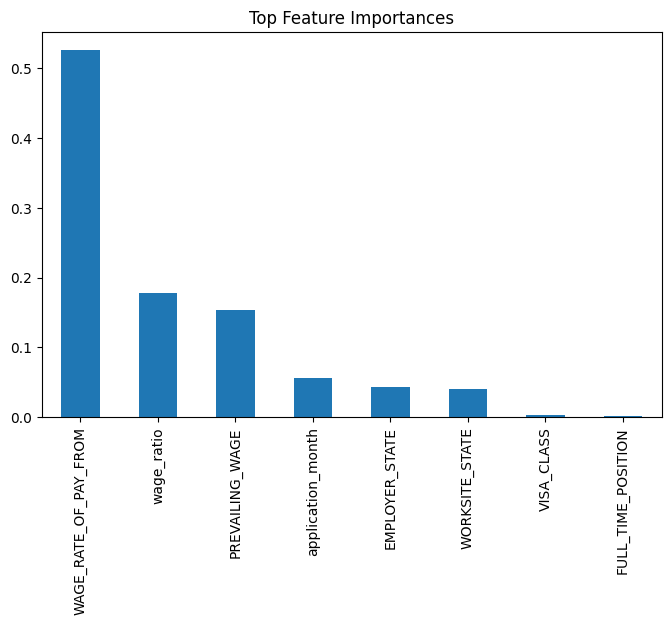

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importance, index=features)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(8,5))
feat_imp.head(10).plot(kind='bar')
plt.title("Top Feature Importances")
plt.show()

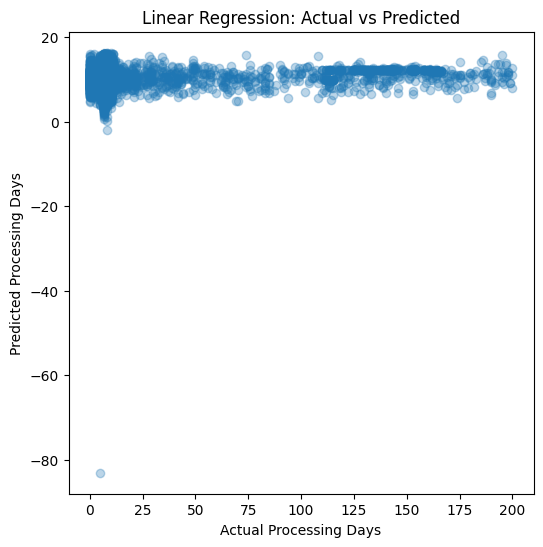

In [38]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lr, alpha=0.3)

plt.xlabel("Actual Processing Days")
plt.ylabel("Predicted Processing Days")

plt.title("Linear Regression: Actual vs Predicted")

plt.show()

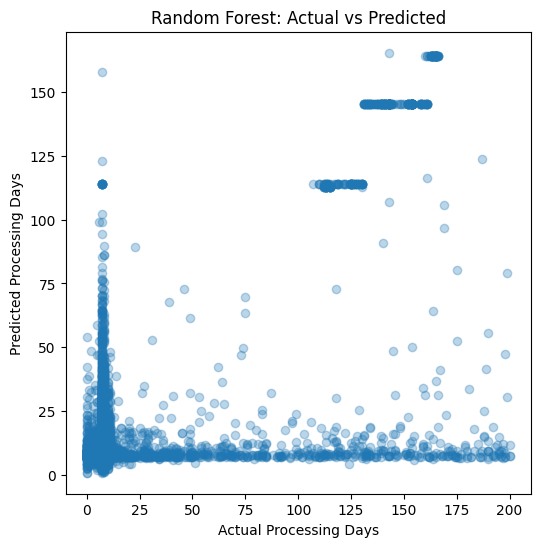

In [39]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf, alpha=0.3)

plt.xlabel("Actual Processing Days")
plt.ylabel("Predicted Processing Days")

plt.title("Random Forest: Actual vs Predicted")

plt.show()

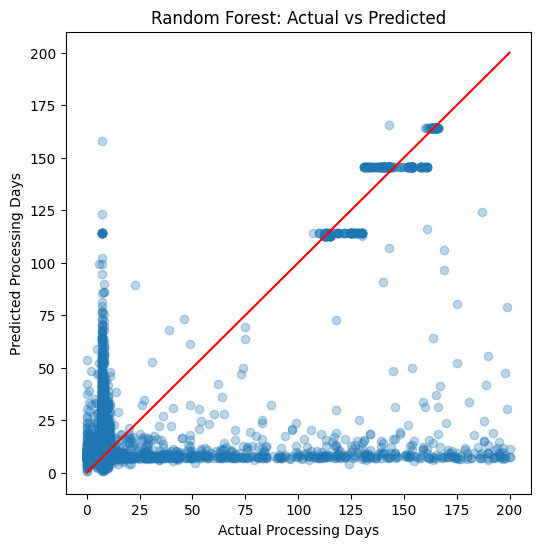

In [40]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf, alpha=0.3)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Processing Days")
plt.ylabel("Predicted Processing Days")

plt.title("Random Forest: Actual vs Predicted")

plt.show()

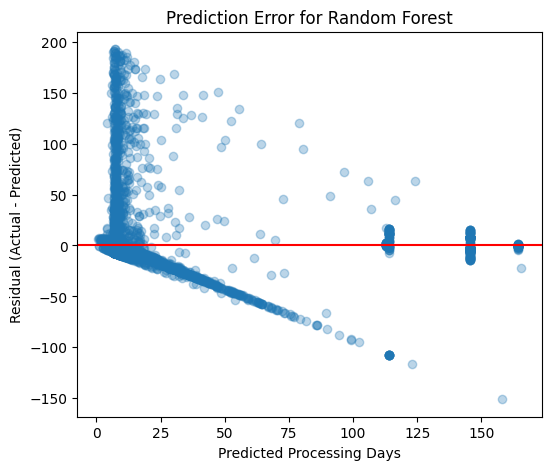

In [41]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(6,5))

plt.scatter(y_pred_rf, residuals, alpha=0.3)

plt.axhline(0, color='red')

plt.xlabel("Predicted Processing Days")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Prediction Error for Random Forest")

plt.show()

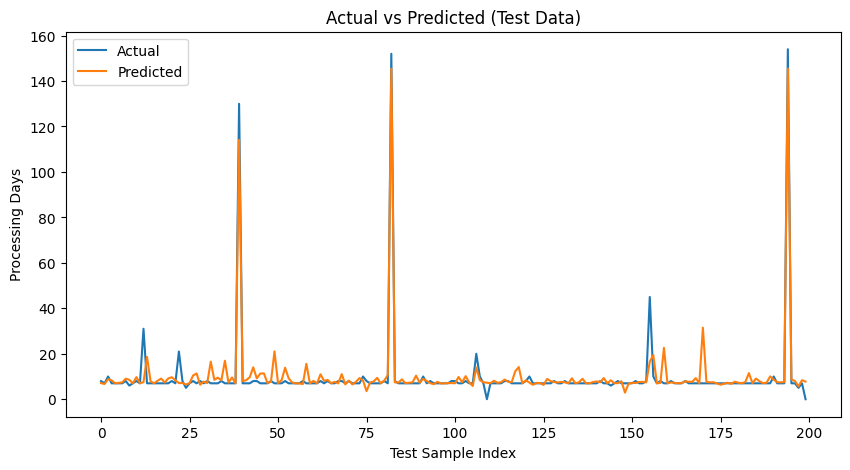

In [42]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values[:200], label="Actual")
plt.plot(y_pred_rf[:200], label="Predicted")

plt.legend()

plt.xlabel("Test Sample Index")
plt.ylabel("Processing Days")
plt.title("Actual vs Predicted (Test Data)")

plt.show()

In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

In [44]:
param_grid = {
    "n_estimators": [100, 150],
    "max_depth": [8, 10, 12],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [5, 10]
}

In [45]:
rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

In [46]:
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 100}


In [47]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))

print("Tuned Random Forest MAE:", mae_best)
print("Tuned Random Forest RMSE:", rmse_best)

Tuned Random Forest MAE: 3.053958166623883
Tuned Random Forest RMSE: 12.981879537731036


In [49]:
print("Linear Regression MAE:", mae_lr)
print("Random Forest MAE:", mae_rf)
print("Tuned Random Forest MAE:", mae_best)

Linear Regression MAE: 5.3521428530841835
Random Forest MAE: 3.350818715188358
Tuned Random Forest MAE: 3.053958166623883


In [50]:
import joblib
joblib.dump(best_rf, "rf_model.pkl")

['rf_model.pkl']

In [51]:
print(X.columns)

Index(['VISA_CLASS', 'FULL_TIME_POSITION', 'EMPLOYER_STATE', 'WORKSITE_STATE',
       'WAGE_RATE_OF_PAY_FROM', 'PREVAILING_WAGE', 'wage_ratio',
       'application_month'],
      dtype='object')


In [52]:
final_model = RandomForestRegressor(random_state=42)
final_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [55]:
import joblib
joblib.dump(best_rf, "model.pkl")

['model.pkl']